In [13]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

wine_dataset = load_wine()
exp = pd.DataFrame(wine_dataset.data, columns=wine_dataset.feature_names)
target = pd.DataFrame(wine_dataset.target, columns=['target'])

df = pd.concat([exp, target], axis=1)

df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


=== 決定木 (Decision Tree) の結果 ===
最適なパラメータ: {'max_depth': 3}
テストデータの正解率: 0.9630


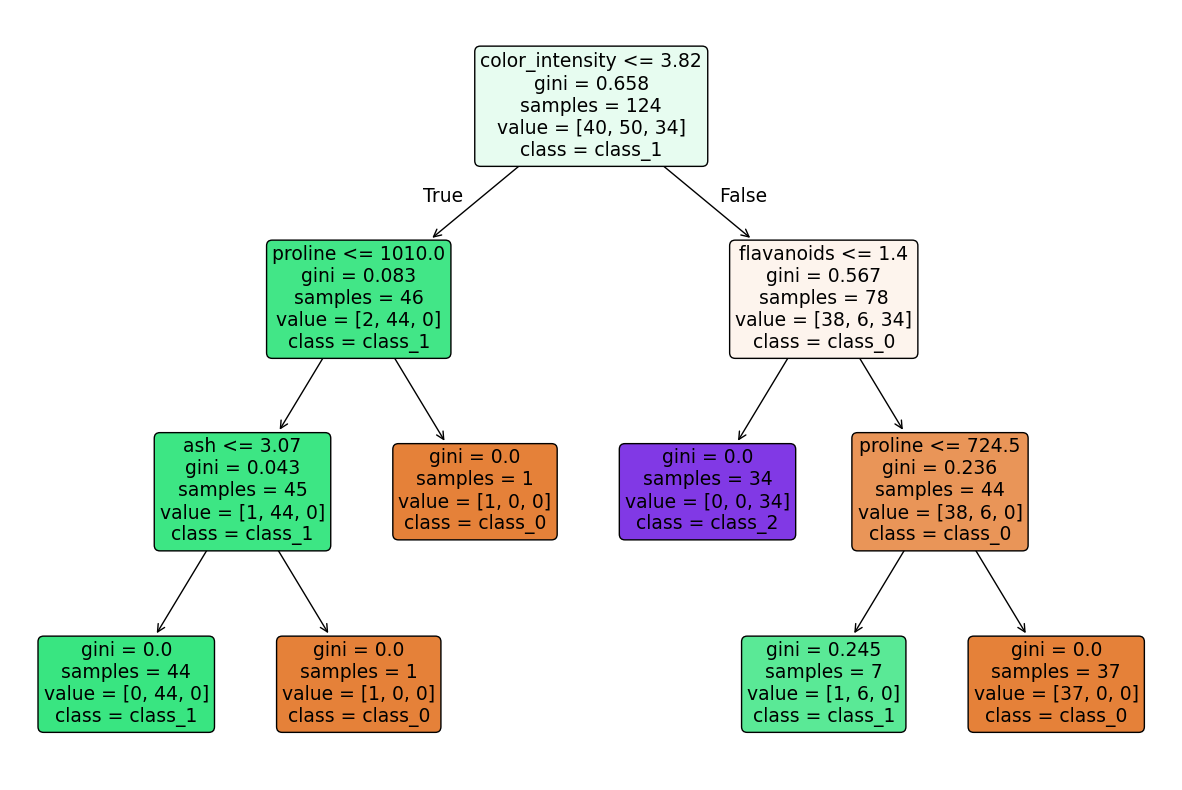

In [3]:
# 決定木

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

X = df.drop('target', axis=1)
y = df['target']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

param_grid_dt = {'max_depth': [2, 3, 4, 5, 6, None]}
dt_model = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("=== 決定木 (Decision Tree) の結果 ===")
print(f"最適なパラメータ: {dt_model.best_params_}")
print(f"テストデータの正解率: {accuracy_score(y_test, y_pred_dt):.4f}")

plt.figure(figsize=(15, 10))
plot_tree(dt_model.best_estimator_,
          feature_names=wine_dataset.feature_names,
          class_names=wine_dataset.target_names,
          filled=True,
          rounded=True)
plt.show()


=== ロジスティック回帰 (Logistic Regression) の結果 ===
最適なパラメータ: {'C': 50}
テストデータの正解率: 0.9815


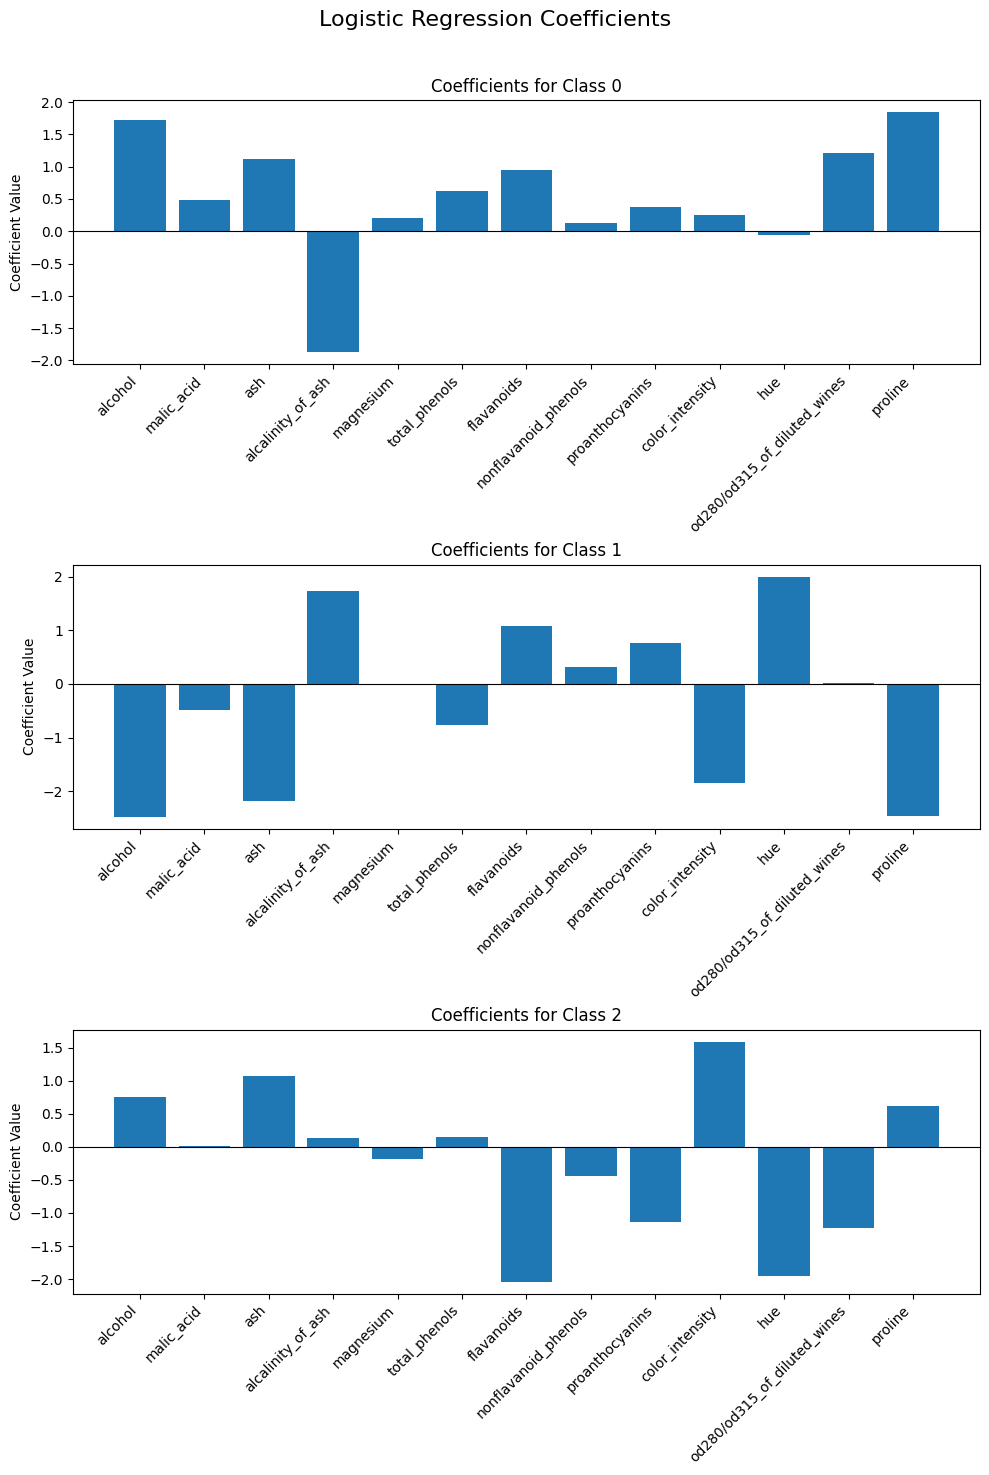

In [4]:
# ロジスティック回帰
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid_lr = {'C': [0.01, 0.1, 1, 10,30 , 50, 60, 100 ,200]}
lr_model = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=5)

lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("\n=== ロジスティック回帰 (Logistic Regression) の結果 ===")
print(f"最適なパラメータ: {lr_model.best_params_}")
print(f"テストデータの正解率: {accuracy_score(y_test, y_pred_lr):.4f}")

import matplotlib.pyplot as plt
import numpy as np

best_lr = lr_model.best_estimator_
coefs = best_lr.coef_

feature_names = X.columns
class_names = ['Class 0', 'Class 1', 'Class 2']

fig, axes = plt.subplots(3, 1, figsize=(10, 15))
fig.suptitle('Logistic Regression Coefficients', fontsize=16)

for i in range(3):
    ax = axes[i]
    ax.bar(range(len(feature_names)), coefs[i], align='center')


    ax.set_xticks(range(len(feature_names)))
    ax.set_xticklabels(feature_names, rotation=45, ha='right')
    ax.set_title(f'Coefficients for {class_names[i]}')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Coefficient Value')

plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

In [12]:
#　多層パーセプトロン
from sklearn.neural_network import MLPClassifier

param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (150,),(50, 50)],
    'alpha': [0.0001, 0.01, 0.1 ]
}

mlp_model = GridSearchCV(
    MLPClassifier(max_iter=1000, random_state=42),
    param_grid_mlp,
    cv=5
)

mlp_model.fit(X_train_scaled, y_train)


y_pred_mlp = mlp_model.predict(X_test_scaled)

print("\n=== 多層パーセプトロン (MLP) の結果 ===")
print(f"最適なパラメータ: {mlp_model.best_params_}")
print(f"テストデータの正解率: {accuracy_score(y_test, y_pred_mlp):.4f}")


=== 多層パーセプトロン (MLP) の結果 ===
最適なパラメータ: {'alpha': 0.0001, 'hidden_layer_sizes': (100,)}
テストデータの正解率: 0.9815


=== ランダムフォレスト (Random Forest) の結果 ===
最適なパラメータ: {'max_depth': 3, 'n_estimators': 50}
テストデータの正解率: 1.0000


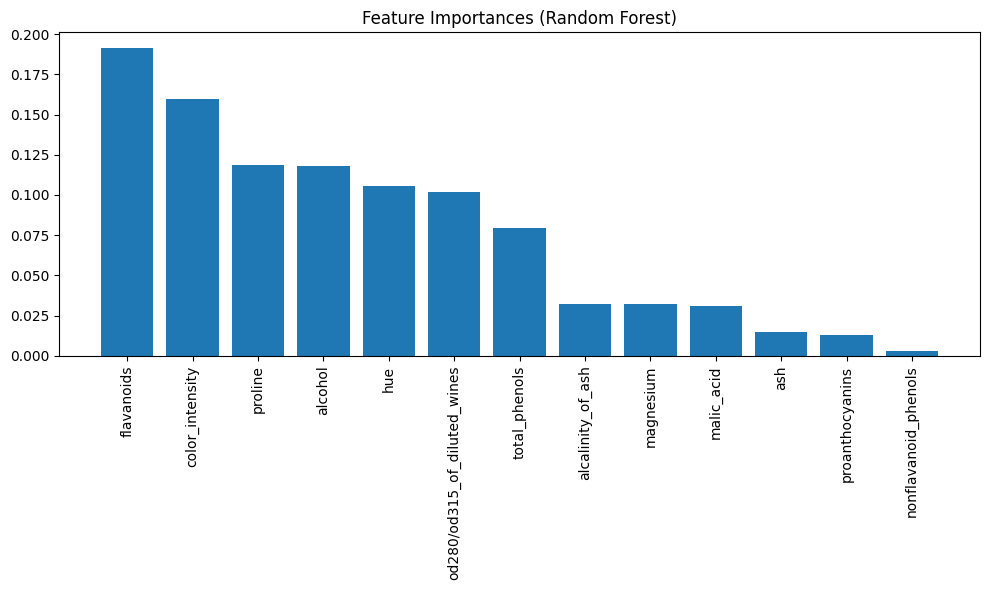

In [6]:
# ランダムフォレスト
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, None]
}

rf_model = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
best_rf = rf_model.best_estimator_

print("=== ランダムフォレスト (Random Forest) の結果 ===")
print(f"最適なパラメータ: {rf_model.best_params_}")
print(f"テストデータの正解率: {accuracy_score(y_test, y_pred_rf):.4f}")

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [wine_dataset.feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()